In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 345kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]


Generator


In [3]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(-1, 1, 28, 28)

Discriminator

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        return self.model(x)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

Training

In [8]:
epochs = 50

for epoch in range(epochs):
    for real_images, _ in loader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # -------------------
        # Train Discriminator
        # -------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_images = G(z)

        D_real = D(real_images)
        D_fake = D(fake_images.detach())

        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # -------------------
        # Train Generator
        # -------------------
        z = torch.randn(batch_size, 100).to(device)
        fake_images = G(z)

        D_fake = D(fake_images)

        loss_G = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

Epoch 1/50 | Loss D: 0.6671 | Loss G: 2.5531
Epoch 2/50 | Loss D: 0.5482 | Loss G: 2.9837
Epoch 3/50 | Loss D: 0.6152 | Loss G: 3.3313
Epoch 4/50 | Loss D: 0.6536 | Loss G: 2.7249
Epoch 5/50 | Loss D: 0.6569 | Loss G: 2.4379
Epoch 6/50 | Loss D: 0.7522 | Loss G: 2.5600
Epoch 7/50 | Loss D: 0.7838 | Loss G: 2.8353
Epoch 8/50 | Loss D: 0.8071 | Loss G: 2.8836
Epoch 9/50 | Loss D: 0.6217 | Loss G: 3.0092
Epoch 10/50 | Loss D: 0.6009 | Loss G: 2.7041
Epoch 11/50 | Loss D: 0.6138 | Loss G: 2.6148
Epoch 12/50 | Loss D: 0.5402 | Loss G: 3.5880
Epoch 13/50 | Loss D: 0.7804 | Loss G: 3.1893
Epoch 14/50 | Loss D: 0.7146 | Loss G: 2.6019
Epoch 15/50 | Loss D: 0.6705 | Loss G: 3.2453
Epoch 16/50 | Loss D: 0.6276 | Loss G: 2.6239
Epoch 17/50 | Loss D: 0.5958 | Loss G: 3.0998
Epoch 18/50 | Loss D: 0.9137 | Loss G: 2.5364
Epoch 19/50 | Loss D: 0.6701 | Loss G: 2.6504
Epoch 20/50 | Loss D: 0.6258 | Loss G: 2.6280
Epoch 21/50 | Loss D: 0.7188 | Loss G: 2.3101
Epoch 22/50 | Loss D: 0.6079 | Loss G: 3.02

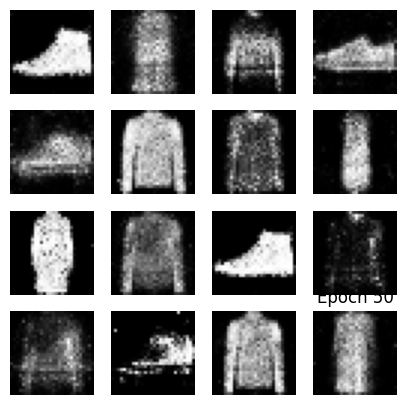

In [9]:
z = torch.randn(16, 100).to(device)
generated = G(z).detach().cpu()

if (epoch + 1) % 5 == 0:
    z = torch.randn(16, 100).to(device)
    generated = G(z).detach().cpu()

    fig, axes = plt.subplots(4, 4, figsize=(5,5))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(generated[i].squeeze(), cmap='gray')
        ax.axis('off')

    plt.title(f"Epoch {epoch+1}")
    plt.show()